In [207]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, SimpleRNN
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [208]:
data = pd.read_csv('BTC-USD.csv')
data.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100


In [209]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3348 entries, 0 to 3347
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       3348 non-null   str    
 1   Open       3348 non-null   float64
 2   High       3348 non-null   float64
 3   Low        3348 non-null   float64
 4   Close      3348 non-null   float64
 5   Adj Close  3348 non-null   float64
 6   Volume     3348 non-null   int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 183.2 KB


In [210]:
data['Date'] = pd.to_datetime(data['Date'])

In [211]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3348 entries, 0 to 3347
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       3348 non-null   datetime64[us]
 1   Open       3348 non-null   float64       
 2   High       3348 non-null   float64       
 3   Low        3348 non-null   float64       
 4   Close      3348 non-null   float64       
 5   Adj Close  3348 non-null   float64       
 6   Volume     3348 non-null   int64         
dtypes: datetime64[us](1), float64(5), int64(1)
memory usage: 183.2 KB


In [212]:
data.set_index('Date',inplace = True)

In [213]:
data.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100


In [214]:
numeric_cols = data.select_dtypes(include = ['int64','float64']).columns
numeric_cols

Index(['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='str')

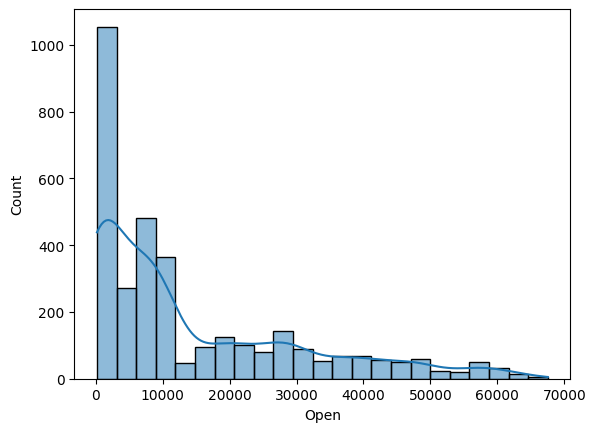

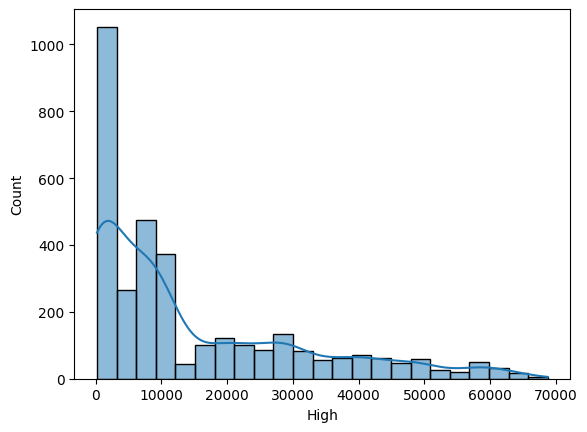

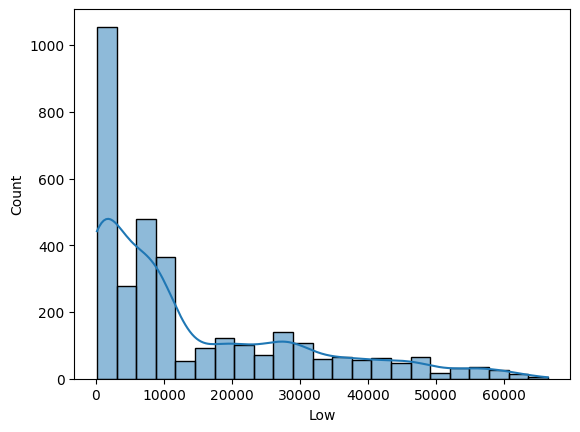

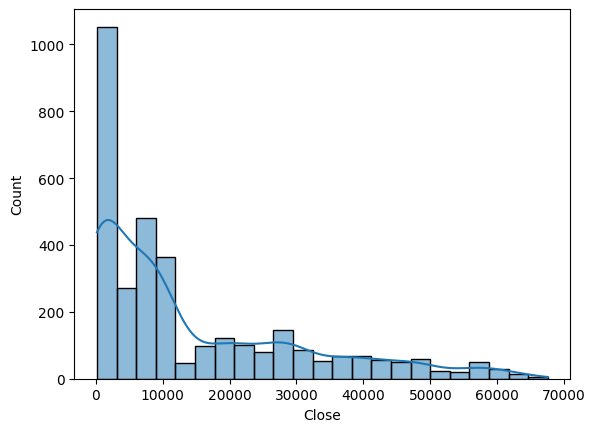

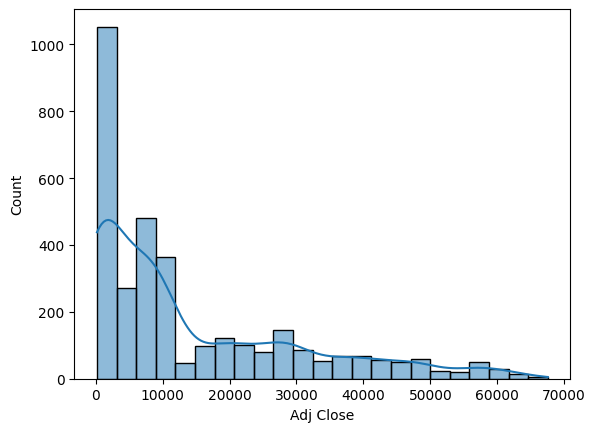

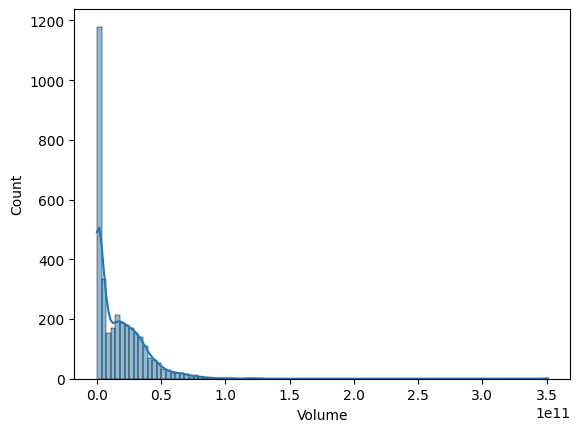

In [215]:
for col in numeric_cols:
    plt.figure()
    sns.histplot(data[col], kde = True)
    plt.show()

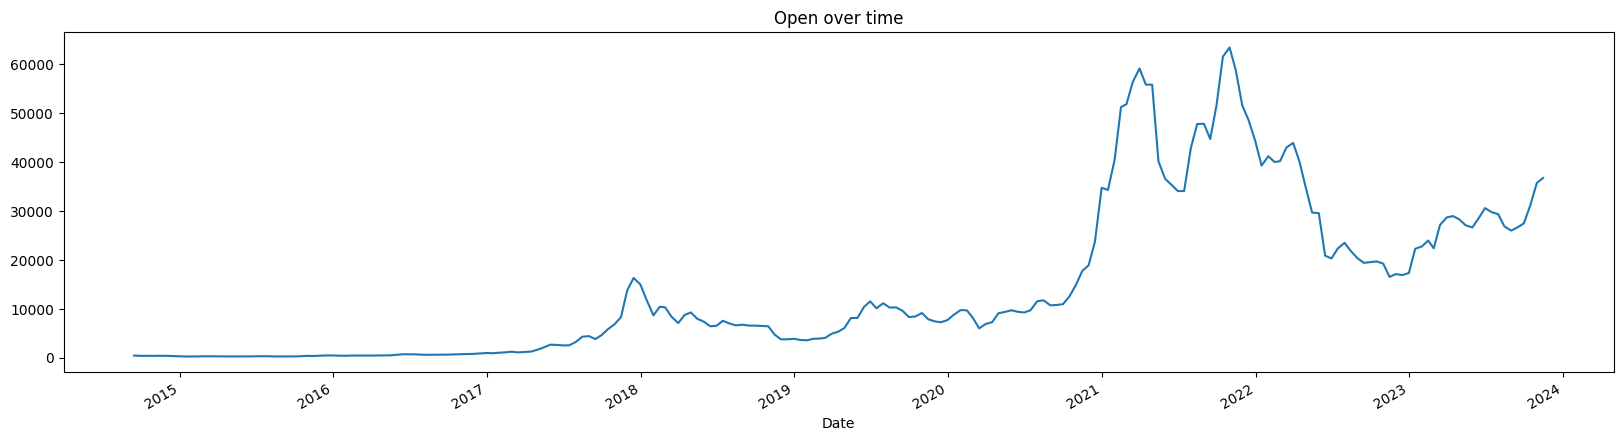

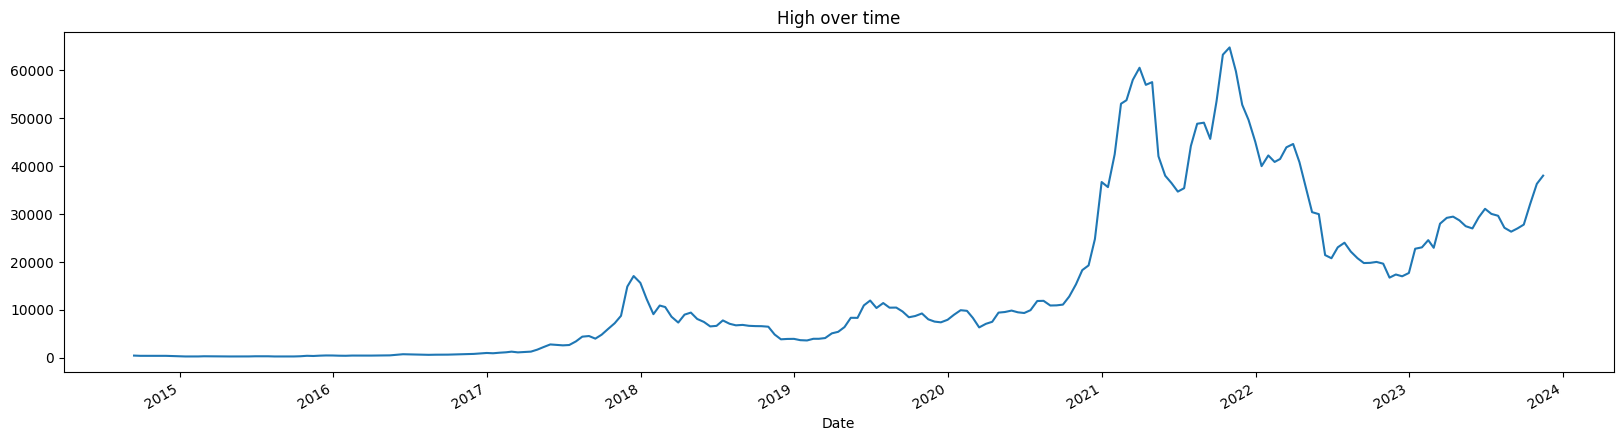

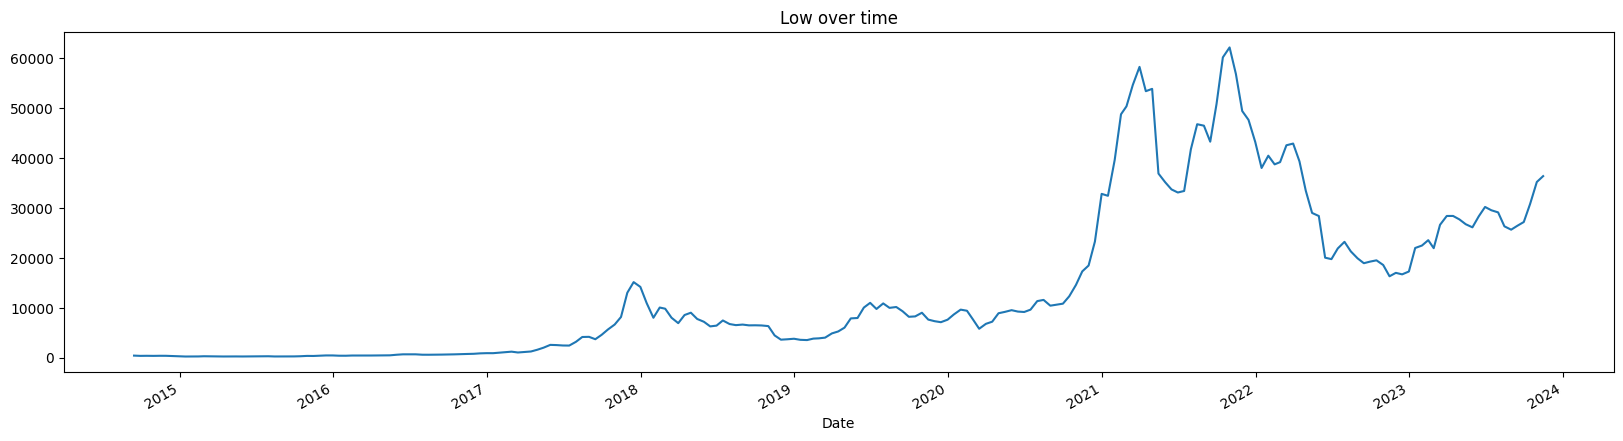

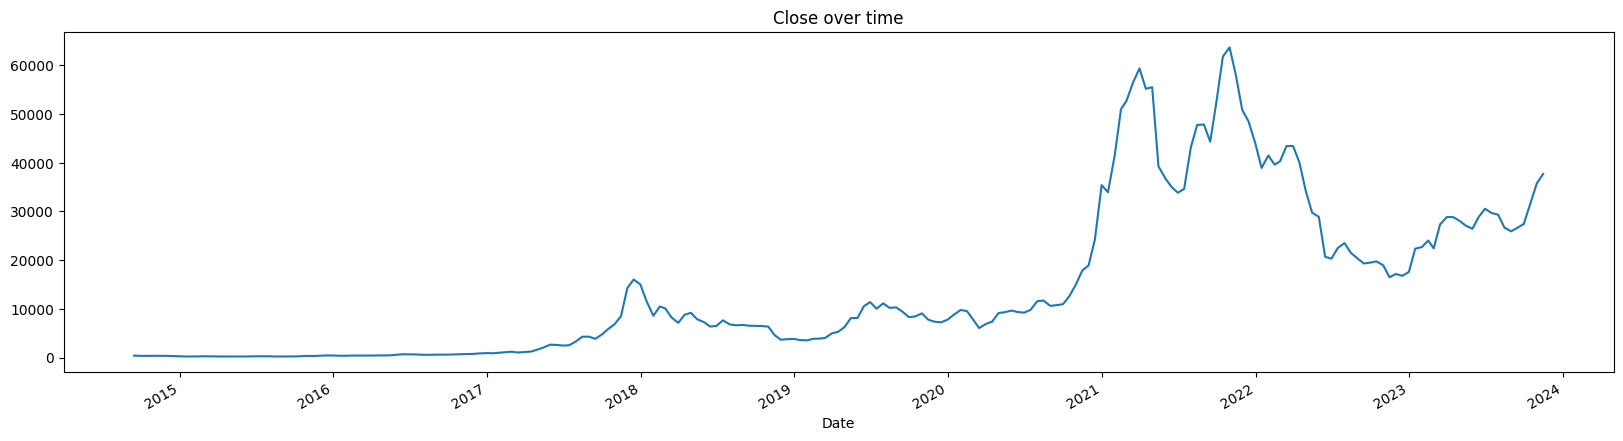

In [216]:
prices = ['Open', 'High', 'Low', 'Close']
for price in prices:
    df_2 = data[[price]].resample('SME').mean().copy()
    df_2[price].plot(title=f"{price} over time", figsize=(20, 5))
    plt.show()

In [217]:
data_2 = data[['Close']].copy()

In [218]:
data_2 = data_2.resample('SME').mean()

In [219]:
data_2.head()

,Close
Date,
2014-09-15,408.739230
2014-09-30,362.163002
2014-10-15,369.049562
2014-10-31,357.645601
2014-11-15,371.905597


In [220]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data_2)

In [221]:
window_size = 12
X = []
y = []
target_dates = data_2.index[window_size:]

for i in range(window_size, len(scaled_data)):
    X.append(scaled_data[i - window_size:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

X_train, X_test, y_train, y_test, dates_train, dates_test = train_test_split(
    X, y, target_dates, test_size=0.2, shuffle=False
)

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

In [222]:
model = Sequential()
model.add(LSTM(units=128, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(units=128))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

c:\Users\victo\OneDrive\Documents\Data science course\Machine-Learning-2\env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [223]:
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.1)

predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions).flatten()
y_test_1 = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

rmse = np.sqrt(np.mean((y_test_1 - predictions)**2))
mae = np.mean(y_test_1 - predictions)
print(f'RMSE: {rmse:.2f}')
print(f'MAE: {mae:.2f}')

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 0.0372 - val_loss: 0.0283
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0156 - val_loss: 0.0394
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0097 - val_loss: 0.1486
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0087 - val_loss: 0.2535
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0095 - val_loss: 0.0827
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0083 - val_loss: 0.0370
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0079 - val_loss: 0.0648
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0071 - val_loss: 0.0431
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0074 - val_loss: 0.0568
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0068 - val_loss: 0.0353
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0059 - val_loss: 0.0362
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0061 - val_lo

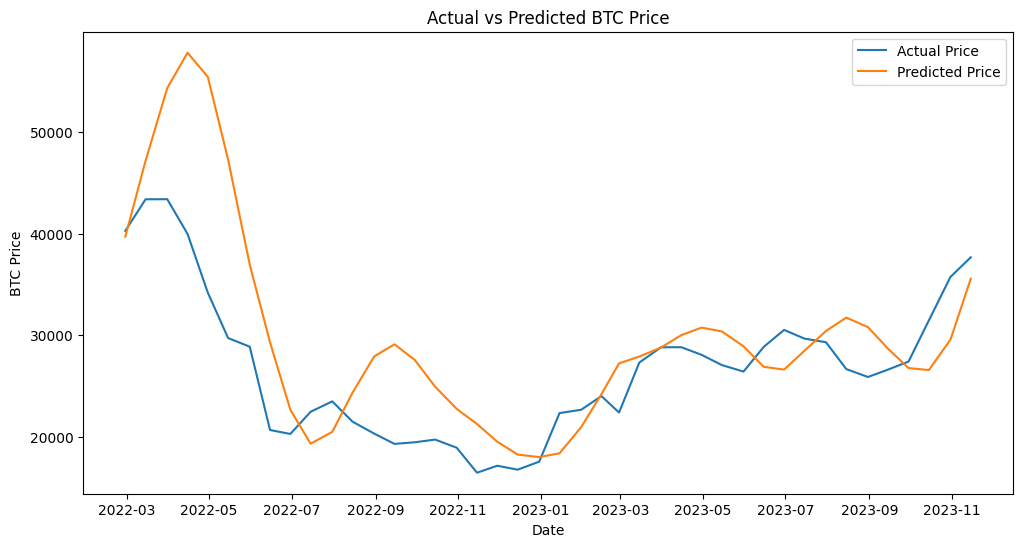

In [224]:
plt.figure(figsize=(12, 6))
plt.plot(dates_test, y_test_1, label='Actual Price')
plt.plot(dates_test, predictions, label='Predicted Price')
plt.title('Actual vs Predicted BTC Price')
plt.xlabel('Date')
plt.ylabel('BTC Price')
plt.legend()
plt.show()

In [225]:
model = Sequential()
model.add(SimpleRNN(units=128, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(SimpleRNN(units=128))
model.add(Dropout(0.2))
model.add(Dense(1))

c:\Users\victo\OneDrive\Documents\Data science course\Machine-Learning-2\env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [226]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [227]:
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.1)

predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions).flatten()
y_test_2 = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

rmse = np.sqrt(np.mean((y_test_2 - predictions)**2))
print(f'RMSE: {rmse:.2f}')

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - loss: 0.1081 - val_loss: 0.6593
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0319 - val_loss: 0.0962
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0135 - val_loss: 0.0863
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0124 - val_loss: 0.0142
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0079 - val_loss: 0.0145
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0079 - val_loss: 0.0958
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0086 - val_loss: 0.0200
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0054 - val_loss: 0.0194
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0063 - val_loss: 0.0395
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0051 - val_loss: 0.0288
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0038 - val_loss: 0.0124
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0040 - val_lo

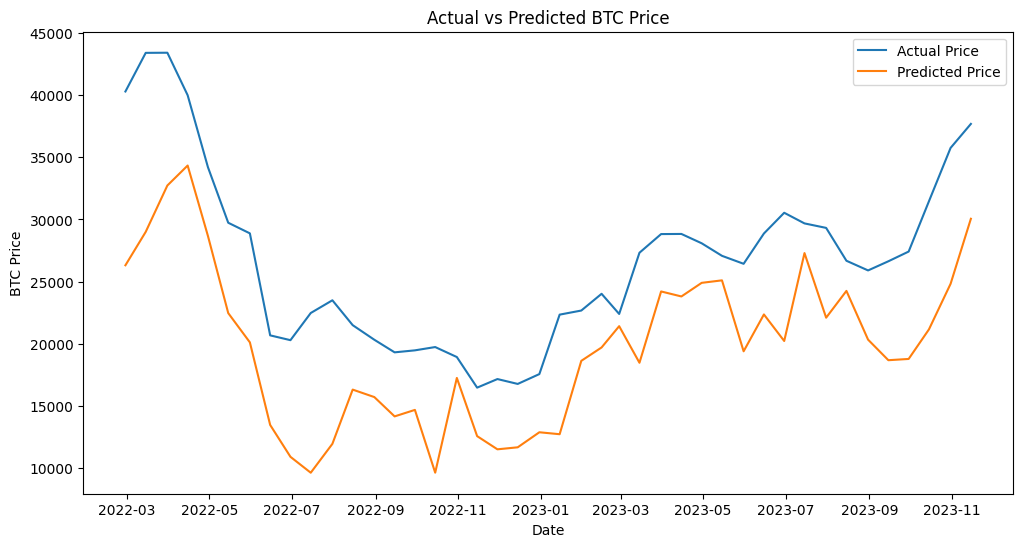

In [229]:
plt.figure(figsize=(12, 6))
plt.plot(dates_test, y_test_2, label='Actual Price')
plt.plot(dates_test, predictions, label='Predicted Price')
plt.title('Actual vs Predicted BTC Price')
plt.xlabel('Date')
plt.ylabel('BTC Price')
plt.legend()
plt.show()